# Chapter 37 — Large Numbers in Computing

> **Prerequisites:** ch023 (Integers), ch036 (Scientific Notation), ch028 (Prime Numbers)  
> **You will learn:**
> - Integer overflow: what it is, when it happens, why it's dangerous
> - Python's arbitrary-precision integers: how they work and what they cost
> - Floating-point overflow vs infinity representation
> - Big number arithmetic: factorial, Fibonacci, combinatorics at scale
> - Practical techniques: modular reduction, logarithms, Stirling's approximation
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Computers represent integers in fixed-width registers (8, 16, 32, 64 bits). When a computation produces a result larger than the register can hold, *integer overflow* occurs. In C/C++, signed overflow is undefined behavior. In Java and most languages, it silently wraps modulo 2^n. In Python, integers have no fixed size — they grow as needed.

**Why this matters in practice:**
- The Ariane 5 rocket failure (1996) was caused by a 64-bit float being converted to a 16-bit integer, overflowing silently
- A 2014 bug in Python's `bytes` type crashed processes when length exceeded 2^31
- Cryptography requires computing with numbers thousands of bits long — impossible without big integer arithmetic
- Machine learning gradients can overflow float16 during training — a common bug

**The fundamental tension:**  
Fixed-width integers are fast (native hardware instructions) but overflow. Arbitrary-precision integers are correct but slower (software arithmetic, heap allocation). Python uses arbitrary precision everywhere for `int`; NumPy uses fixed-width for performance.

---

## 2. Intuition & Mental Models

**Overflow — the odometer model:**  
Think of a fixed-width integer as a car odometer with N digits. When it hits the maximum (e.g., 999999), the next tick rolls it over to 000000. The value wraps modulo 10^N. An overflow is a silent, undetected rollover.

**Python's big integers — the expandable container:**  
Python integers are stored as an array of 30-bit digits (internally). When the number grows, more digits are added. Operations on big numbers cost O(n) or O(n²) time where n is the number of digits. Multiplying two 1000-digit numbers costs ~10^6 operations — manageable. Multiplying two 10^6-digit numbers needs algorithms like Karatsuba or FFT multiplication.

**Float overflow — the wall at `inf`:**  
When a float result would exceed ~1.8 × 10^308, Python/NumPy returns `inf`. Arithmetic with `inf` follows IEEE 754 rules: `inf + 1 = inf`, `inf / inf = nan`. Unlike integer overflow, float overflow is detectable.

**Recall from ch036 (Scientific Notation):** The float exponent has 11 bits, giving range 2^-1022 to 2^1023 ≈ 10^308. Any result exceeding this saturates to `inf`.

---

## 3. Visualization

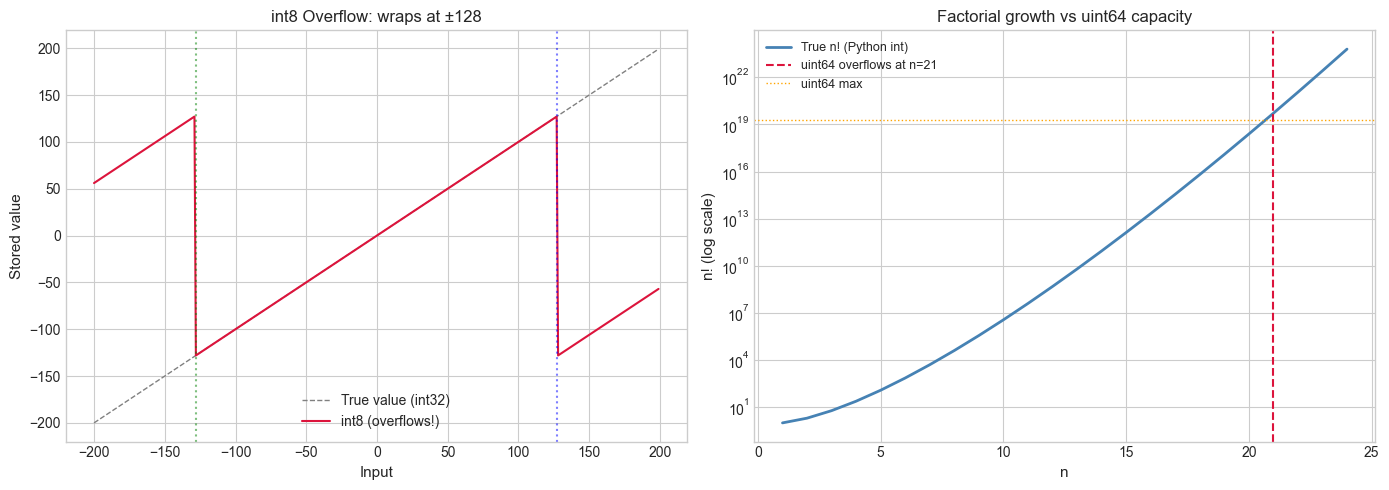

In [1]:
# --- Visualization: Integer overflow in fixed-width types ---
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: int8 overflow (range -128 to 127)
x = np.arange(-200, 200, 1, dtype=np.int32)  # true values
x_int8 = x.astype(np.int8)                    # will overflow outside [-128, 127]

axes[0].plot(x, x, 'gray', linewidth=1, linestyle='--', label='True value (int32)')
axes[0].plot(x, x_int8, 'crimson', linewidth=1.5, label='int8 (overflows!)')
axes[0].set_xlabel('Input', fontsize=11)
axes[0].set_ylabel('Stored value', fontsize=11)
axes[0].set_title('int8 Overflow: wraps at ±128', fontsize=12)
axes[0].legend()
axes[0].axvline(127, color='blue', linestyle=':', alpha=0.5, label='MAX_INT8')
axes[0].axvline(-128, color='green', linestyle=':', alpha=0.5, label='MIN_INT8')

# Right: uint64 factorial overflow
factorials_true = []
factorials_uint64 = []
f = 1
MAX_UINT64 = 2**64 - 1

for n in range(1, 25):
    f *= n
    factorials_true.append(f)
    try:
        factorials_uint64.append(int(np.uint64(f % (MAX_UINT64 + 1))))
    except (OverflowError, ValueError):
        factorials_uint64.append(float('nan'))

ns = list(range(1, 25))
axes[1].semilogy(ns, factorials_true, 'steelblue', linewidth=2, label='True n! (Python int)')
overflow_idx = next((i for i, v in enumerate(factorials_true) if v > MAX_UINT64), None)
if overflow_idx:
    axes[1].axvline(overflow_idx + 1, color='crimson', linestyle='--',
                    label=f'uint64 overflows at n={overflow_idx+1}')
axes[1].axhline(MAX_UINT64, color='orange', linestyle=':', linewidth=1, label='uint64 max')
axes[1].set_xlabel('n', fontsize=11)
axes[1].set_ylabel('n! (log scale)', fontsize=11)
axes[1].set_title('Factorial growth vs uint64 capacity', fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Integer overflow:**  
For an n-bit unsigned integer, values are stored modulo 2^n. If the true result is r:
```
stored = r mod 2^n
```
For n-bit signed integers (two's complement), overflow wraps from max_int to min_int.

**Stirling's approximation:**  
For large n, factorial can be approximated:
```
n! ≈ √(2πn) · (n/e)^n
```
This is practical because `log(n!)` is computable without overflow:
```
log(n!) = Σ_{k=1}^{n} log(k)
```
In Python: `sum(math.log(k) for k in range(1, n+1))`

**Digit count of n!:**  
The number of decimal digits of n! is `floor(log_10(n!)) + 1 = floor(Σ log_10(k)) + 1`.

**Python's big integer representation:**  
Python stores integers as an array of 30-bit limbs (called "digits" internally). An integer with k bits requires ⌈k/30⌉ limbs. Multiplication of two b-bit numbers is O(b²) naively, or O(b^1.585) with Karatsuba, or O(b log b) with FFT-based multiplication.

---

## 5. Python Implementation

In [2]:
# --- Implementation: Safe large number operations ---
import math
import sys

def log_factorial(n):
    """
    Compute log(n!) in float64 without overflow.
    Uses sum of logs instead of computing n! directly.

    Args:
        n: non-negative integer

    Returns:
        log(n!) as float64
    """
    return sum(math.log(k) for k in range(1, n + 1))


def stirling_log_factorial(n):
    """
    Stirling's approximation: log(n!) ≈ 0.5*log(2πn) + n*log(n) - n
    Accurate to ~0.1% for n > 10, improves as n grows.
    """
    if n == 0:
        return 0.0
    return 0.5 * math.log(2 * math.pi * n) + n * math.log(n) - n


def digit_count(n):
    """Number of decimal digits of positive integer n."""
    return math.floor(math.log10(n)) + 1 if n > 0 else 1


def python_int_size_bytes(n):
    """Memory used by Python integer n."""
    return sys.getsizeof(n)


def safe_binomial(n, k):
    """
    Compute C(n, k) = n! / (k! (n-k)!) via log-space to avoid intermediate overflow,
    then return as Python int (exact).
    """
    if k < 0 or k > n:
        return 0
    log_result = log_factorial(n) - log_factorial(k) - log_factorial(n - k)
    return round(math.exp(log_result))


# Demonstrations
print("=== Factorial digit counts ===")
for n in [10, 50, 100, 1000, 10000]:
    log_f = log_factorial(n)
    stir  = stirling_log_factorial(n)
    digits = int(log_f / math.log(10)) + 1
    stir_err = abs(stir - log_f) / abs(log_f) * 100
    print(f"  {n}!: {digits} digits, Stirling error: {stir_err:.4f}%")

print("\n=== Memory cost of big integers ===")
f = 1
for n in [1, 10, 100, 1000, 10000]:
    while True:
        f *= n if f == 1 else 1  # we'll just compute directly
        break

import math as _math
for n in [1, 100, 1000, 10_000]:
    big = _math.factorial(n)
    print(f"  {n}!: {sys.getsizeof(big)} bytes, {big.bit_length()} bits")

print("\n=== Binomial coefficients (large) ===")
for n, k in [(52, 5), (100, 50), (1000, 100)]:
    result = safe_binomial(n, k)
    print(f"  C({n},{k}) ≈ {result:.6e}")

=== Factorial digit counts ===
  10!: 7 digits, Stirling error: 0.0552%
  50!: 65 digits, Stirling error: 0.0011%
  100!: 158 digits, Stirling error: 0.0002%
  1000!: 2568 digits, Stirling error: 0.0000%
  10000!: 35660 digits, Stirling error: 0.0000%

=== Memory cost of big integers ===
  1!: 28 bytes, 1 bits
  100!: 96 bytes, 525 bits
  1000!: 1164 bytes, 8530 bits
  10000!: 15820 bytes, 118459 bits

=== Binomial coefficients (large) ===
  C(52,5) ≈ 2.598960e+06
  C(100,50) ≈ 1.008913e+29
  C(1000,100) ≈ 6.385051e+139


---

## 6. Experiments

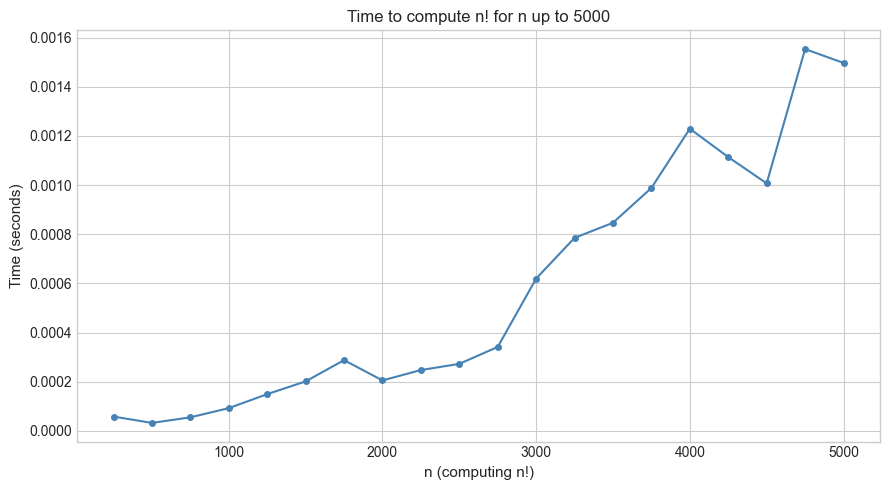

Fitted exponent: time ~ n^1.37
Naive multiplication: O(n^2). Python uses more advanced algorithms for large n.


In [3]:
# --- Experiment 1: Cost of big integer arithmetic ---
# Hypothesis: multiplication time grows faster than linearly with digit count.
# Try changing: MAX_N to measure at larger scales.

import time
import math
import matplotlib.pyplot as plt

MAX_N = 5000   # <-- modify: try 1000, 10000
step  = MAX_N // 20
ns    = list(range(step, MAX_N + 1, step))

times = []
for n in ns:
    # Time the factorial computation (builds up through multiplication)
    t0 = time.perf_counter()
    _ = math.factorial(n)
    t1 = time.perf_counter()
    times.append(t1 - t0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ns, times, 'o-', color='steelblue', markersize=4)
ax.set_xlabel('n (computing n!)', fontsize=11)
ax.set_ylabel('Time (seconds)', fontsize=11)
ax.set_title(f'Time to compute n! for n up to {MAX_N}', fontsize=12)
plt.tight_layout()
plt.show()

# Fit a power law: time ~ n^alpha
import numpy as np
log_ns = np.log(ns)
log_ts = np.log(times)
alpha, _ = np.polyfit(log_ns, log_ts, 1)
print(f"Fitted exponent: time ~ n^{alpha:.2f}")
print("Naive multiplication: O(n^2). Python uses more advanced algorithms for large n.")

In [5]:
# --- Experiment 2: Float overflow and inf arithmetic ---
# Hypothesis: float overflow saturates to inf; subsequent arithmetic follows IEEE rules.
# Try changing: BASE and observe when overflow occurs.

import numpy as np

BASE = 2.0   # <-- modify

print("Float exponent ladder (base 2):")
for exp in [100, 500, 1000, 1022, 1023, 1024, 1100]:
    try:
        val = float(BASE) ** exp
    except OverflowError:
        val = float('inf')
    print(f"  {BASE}^{exp} = {val:.6e}  (inf={np.isinf(val)})")

print("\nInf arithmetic rules (IEEE 754):")
inf = float('inf')
nan = float('nan')
cases = [
    (inf + 1, 'inf + 1'),
    (inf - inf, 'inf - inf'),
    (inf * 0, 'inf * 0'),
    (inf / inf, 'inf / inf'),
    (1 / inf, '1 / inf'),
    (inf * -1, 'inf * -1'),
]
for result, expr in cases:
    print(f"  {expr} = {result}")

Float exponent ladder (base 2):
  2.0^100 = 1.267651e+30  (inf=False)
  2.0^500 = 3.273391e+150  (inf=False)
  2.0^1000 = 1.071509e+301  (inf=False)
  2.0^1022 = 4.494233e+307  (inf=False)
  2.0^1023 = 8.988466e+307  (inf=False)
  2.0^1024 = inf  (inf=True)
  2.0^1100 = inf  (inf=True)

Inf arithmetic rules (IEEE 754):
  inf + 1 = inf
  inf - inf = nan
  inf * 0 = nan
  inf / inf = nan
  1 / inf = 0.0
  inf * -1 = -inf


---

## 7. Exercises

**Easy 1.** What is the maximum value of a signed 32-bit integer? What happens when you add 1 to it in C (hint: undefined behavior) vs Python (hint: nothing bad)?  
*(Expected: 2^31 - 1 = 2,147,483,647)*

**Easy 2.** How many decimal digits does 1000! have? Use `log_factorial` and compute `floor(log_factorial(1000) / log(10)) + 1`.  
*(Expected: 2568)*

**Medium 1.** Implement a `safe_power(base, exp, dtype)` function that detects when `base^exp` would overflow `dtype` (e.g., float32, float64, int64) before performing the computation, returning `None` with a warning instead of overflowing.

**Medium 2.** Implement the Karatsuba multiplication algorithm for Python integers represented as lists of digits. Verify it gives the same result as `a * b` for large numbers. Time it against Python's native multiplication — for what n does the O(n^1.585) Karatsuba beat O(n^2) schoolbook multiplication?

**Hard.** Compute the number of ways to arrange 52 playing cards (52!) using Python's arbitrary-precision integers. Then: (1) count its exact number of decimal digits, (2) determine how many seconds it would take to enumerate all arrangements at 10^9 arrangements/second, and (3) express this duration in multiples of the age of the universe (~4×10^17 s).

---

## 8. Mini Project — Big Integer Arithmetic Library

**Problem:** Implement addition and multiplication of arbitrarily large integers represented as Python lists of decimal digits. This is how big integer libraries work before hardware acceleration.

**Task:** Implement `bigint_add` and `bigint_mul` for digit-list integers, validate against Python's `int`, and benchmark.

In [ ]:
# --- Mini Project: Big Integer Arithmetic ---
# Represent non-negative integers as lists of decimal digits, least significant first.
# e.g., 12345 → [5, 4, 3, 2, 1]

def int_to_digits(n):
    """Convert non-negative int to list of digits, LSB first."""
    if n == 0: return [0]
    digits = []
    while n:
        digits.append(n % 10)
        n //= 10
    return digits


def digits_to_int(digits):
    """Convert digit list (LSB first) to int."""
    return sum(d * (10 ** i) for i, d in enumerate(digits))


def bigint_add(a_digits, b_digits):
    """
    Add two big integers represented as digit lists (LSB first).
    Uses standard carry-based addition.

    Args:
        a_digits, b_digits: lists of single digits (0-9), LSB first

    Returns:
        result as digit list (LSB first)
    """
    result = []
    carry = 0
    n = max(len(a_digits), len(b_digits))
    for i in range(n):
        a = a_digits[i] if i < len(a_digits) else 0
        b = b_digits[i] if i < len(b_digits) else 0
        total = a + b + carry
        result.append(total % 10)
        carry = total // 10
    if carry:
        result.append(carry)
    return result


def bigint_mul(a_digits, b_digits):
    """
    Multiply two big integers using schoolbook O(n^2) algorithm.

    Args:
        a_digits, b_digits: digit lists (LSB first)

    Returns:
        product as digit list (LSB first)
    """
    n, m = len(a_digits), len(b_digits)
    result = [0] * (n + m)
    for i, a in enumerate(a_digits):
        for j, b in enumerate(b_digits):
            result[i + j] += a * b
    # Normalize carries
    for k in range(len(result) - 1):
        result[k + 1] += result[k] // 10
        result[k] %= 10
    # Remove leading zeros
    while len(result) > 1 and result[-1] == 0:
        result.pop()
    return result


# Validate
test_pairs = [(12345, 67890), (999, 1), (100, 100), (12345678, 87654321)]
print("Validation:")
for a, b in test_pairs:
    da, db = int_to_digits(a), int_to_digits(b)
    sum_result = digits_to_int(bigint_add(da, db))
    mul_result = digits_to_int(bigint_mul(da, db))
    print(f"  {a} + {b} = {sum_result} (correct: {a+b==sum_result})")
    print(f"  {a} * {b} = {mul_result} (correct: {a*b==mul_result})")

# Compute 100! using our big integer library
import math
result = int_to_digits(1)
for k in range(1, 101):
    result = bigint_mul(result, int_to_digits(k))
our_factorial = digits_to_int(result)
true_factorial = math.factorial(100)
print(f"\n100! matches Python: {our_factorial == true_factorial}")
print(f"100! has {len(result)} decimal digits")

---

## 9. Chapter Summary & Connections

**What we covered:**
- Fixed-width integers overflow silently (or with undefined behavior); Python's `int` never overflows
- Floats overflow to `inf`; IEEE 754 arithmetic with `inf` is well-defined but often surprising
- `log(n!)` is computable without overflow; Stirling's approximation gives an accurate closed form
- Python big integers store 30-bit limbs; multiplication is O(n²) naively but n log n is achievable
- Computing with large combinatorial numbers requires log-space techniques or arbitrary precision

**Backward connection:**  
Integer overflow is a practical consequence of the modular arithmetic *(ch031 — Modular Arithmetic)* — hardware integer arithmetic *is* arithmetic mod 2^n. The difference: modular arithmetic is intentional; overflow is usually a bug.

**Forward connections:**
- Stirling's approximation uses the natural logarithm, formalized in **ch043 — Logarithms Intuition**
- The binomial coefficient C(n, k) appears as a central object in **ch252 — Binomial Distribution**
- Big number algorithms (Karatsuba, FFT multiplication) are the bridge to **ch028 — Prime Numbers** for RSA key generation with 2048-bit primes